TME CORRELATION

In [1]:
%pip install nbformat


[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

1. Toy dataset: Correlation

In [3]:
coffee = pd.read_csv('coffee_effects.csv')
coffee.head(2)

,caffeine_consumption_mg,productivity,break_duration,heart_rate
0,79.467201,0.840200,45.000110,120.035923
1,73.403995,0.823679,44.999979,119.868655


In [4]:
coffee_corr = coffee.corr()
display(coffee_corr)

,caffeine_consumption_mg,productivity,break_duration,heart_rate
caffeine_consumption_mg,1.000000,-0.156541,0.876037,0.366205
productivity,-0.156541,1.000000,-0.136161,0.428721
break_duration,0.876037,-0.136161,1.000000,0.322293
heart_rate,0.366205,0.428721,0.322293,1.000000


<Axes: >

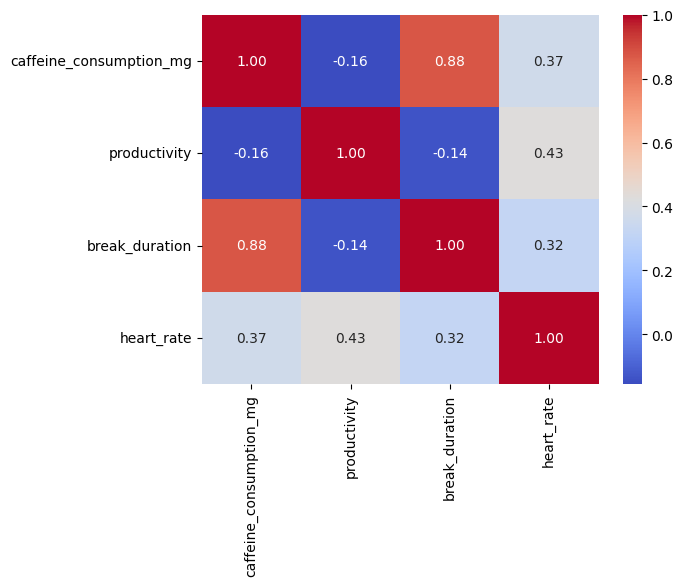

In [5]:
sns.heatmap(coffee_corr, annot=True, cmap='coolwarm', fmt=".2f")

<Axes: >

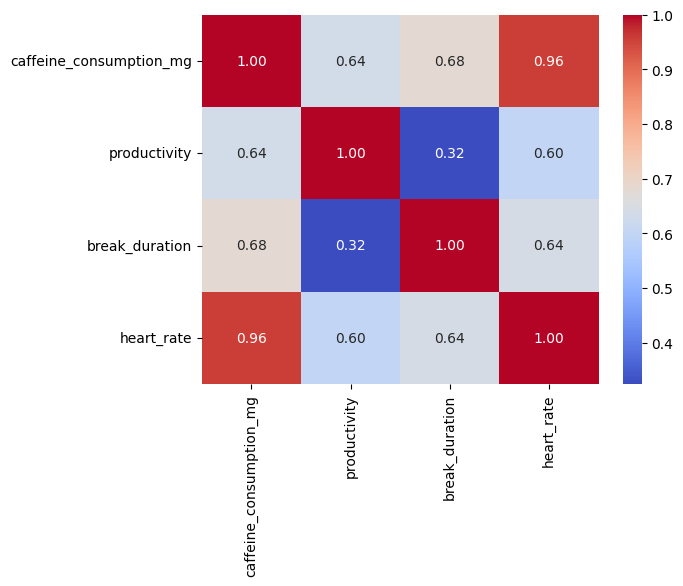

In [6]:
coffee_cor_sp = coffee.corr(method='spearman')
sns.heatmap(coffee_cor_sp, annot=True, cmap='coolwarm', fmt=".2f")

### (e) Observe the correlation values and try to interprete the relation between the variables
- Looking at Pearson correlation we can observe that the biggest correlation is between caffeine consumption and break duration (0.88). Also, heart rate is almost equally correlated with caffeine consumption, productivity and break duration (0.32-0.43). Productivity and coffeine consumption are the less correlated (-0.16) as well as break duration and productivity (-0.14)

- Looking at Spearman correlation, we can have some more details about those correlations. For instance, heart rate highly increases when caffeine consumption increases (0.96). As for break duration and productivity, they are quite correlated too (0.64) but less than two previous variables. The less correlated variables are break duration and productivity (0.34). 

In [10]:

y_vars = coffee.drop(columns=['caffeine_consumption_mg']).columns
for y_var in y_vars:
    fig = px.scatter(coffee, x='caffeine_consumption_mg', y=y_var, title=f"Caffeine Consumption vs {y_var}")
    fig.show()
    # plt.show()
    # px.scatter(coffee, x='caffeine_consumption_mg', y='break_duration')
    # # plt.show()
    # px.scatter(coffee, x='caffeine_consumption_mg', y='heart_rate')

### (g)
- Caffeine cons vs productivity: it's not monotonous neither linear. When coffeine consumption is tiny, not higher than ~223mg, the productivity is increasing. However, when it exceeds ~223mg the productivity decreases.
- Caffeine consumption vs break duration : it's linear. The more caffeine is consumed the bigger is the break duration
- Caffeine cons vs heart rate: it's reminds of logarithmic function. A little increase of caffeine higly increases heart rate but starting from ~100mg the heart rate stays high almost at the same rate.

### (h)
- Company should offer free caffeine at limited quantities to increase productivity for a short period as we can observe that it increases the break duration. In addition, it should be offered not more than ~200mg to not decrease the productivity, but make a warning for those who have heart problmes or sensibility to ensure that heart rate is safe for life. However, for a long period or a whole day it's not recommended because high productivity would be probably compensated with long break durations.

### variance of a variable

In [11]:
def variance(df, v):
    serie = df[v].dropna()
    mean = serie.mean()
    variance_res = 0
    for i in df[v]:
        variance_res += (i - mean)**2
    return variance_res/(len(df[v]) -1 ) 

print(variance(coffee, 'heart_rate'))
print(coffee['heart_rate'].var())

55.25887814360772
55.2588781436078
